# Introduction to pyjeo

**Material provided by Dr. Pieter Kempeneers (European Commission, Joint Research Centre)**

[pyjeo](https://pyjeo.readthedocs.io) is the follow up of [PKTOOLS](http://pktools.nongnu.org/html/index.html), a suite of utilities written in C++ for image processing with a focus on remote sensing applications. It is distributed under a General Public License (GPLv3) as a Python package.

In a nutshell, the main differences between pyjeo and pktools from a user's perspective are:

- pyjeo is a Python package should be run in a **Python environment**, whereas pktools applications are run from the command line (e.g., in a bash shell)
- pyjeo runs with images entirely **in memory**, whereas pktools runs most applications line per line. This makes pyjeo considerably faster, but with a larger memory footprint. However, there are some methods implemented in pyjeo to reduce the memory footprint by tiling the image


Run the following script to perform the installation of pyjeo

    sudo apt update
    sudo apt upgrade -y  
    cd ~/Downloads
    wget https://raw.githubusercontent.com/selvaje/SE_data/main/exercise/install_pyjeo.sh
    sudo install_pyjeo.sh



Import Python modules

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from datetime import datetime
import pyjeo as pj

ModuleNotFoundError: No module named 'pyjeo'

Call the inline help function for [pj.geometry.warp](https://pyjeo.readthedocs.io/en/latest/3_reference.html#geometry.warp)

In [2]:
help(pj.geometry.warp)

NameError: name 'pj' is not defined

## Jim: a geospatial raster dataset object

Open an image and show its properties

In [3]:
jim = pj.Jim('geodata/vegetation/ETmean08-11.tif')

NameError: name 'pj' is not defined

In [4]:
jim.properties.nrOfCol()

NameError: name 'jim' is not defined

A Jim object is a geospatial dataset within a coordinate reference system

In [5]:
jim.properties.getProjection()

NameError: name 'jim' is not defined

From [gdal](https://gdal.org/tutorials/geotransforms_tut.html#introduction-to-geotransforms): "A geotransform is an affine transformation from the image coordinate space (row, column), also known as (pixel, line) to the georeferenced coordinate space (projected or geographic coordinates)"

Geotransform is an array with 6 items:

[0] top left x

[1] w-e pixel resolution

[2] rotation, 0 if image is “north up”

[3] top left y

[4] rotation, 0 if image is “north up”

[5] n-s pixel resolution

In [6]:
jim.properties.getGeoTransform()

NameError: name 'jim' is not defined

We have a single band and single plane raster object

In [7]:
jim.properties.nrOfBand()

NameError: name 'jim' is not defined

In [8]:
jim.properties.nrOfPlane()

NameError: name 'jim' is not defined

Open a second GeoTIFF image of the same dimension

In [9]:
gpp = pj.Jim('geodata/vegetation/GPPmean08-11.tif')

NameError: name 'pj' is not defined

Stack this image to the existing bands of jim, creating a multi-band jim object

In [10]:
jim.geometry.stackBand(gpp)

NameError: name 'jim' is not defined

In [11]:
jim.properties.nrOfBand()

NameError: name 'jim' is not defined

## Exercise 1: stackBand function vs. method

Create a new jim object `jim_stacked` using the [stackBand](https://pyjeo.readthedocs.io/en/latest/3_reference.html#geometry.stackBand) function instead of the [stackBand](https://pyjeo.readthedocs.io/en/latest/3_reference.html#geometry._Geometry.stackBand) method. It should contain two bands, one for `ETmean08-11.tif` and one for `GPPmean08-11.tif`.

## Labeled dimensions

Let's label the dimensions

In [12]:
bandnames = ['ET', 'GPP']
planenames = [datetime.strptime('2019-08-11','%Y-%m-%d')]
jim.properties.setDimension({'band' : bandnames, 'plane' : planenames})

NameError: name 'jim' is not defined

In [13]:
jim.properties.getDimension('band')

NameError: name 'jim' is not defined

In [14]:
jim.properties.getDimension('plane')

NameError: name 'jim' is not defined

## Exercise 2: cropBand using numbered and labeled index

Crop second band as a new image (index starts from 0)

In [15]:
jim1 = pj.geometry.cropBand(jim, 1)

NameError: name 'pj' is not defined

Create a new jim object `gpp` that contains the second band using the [cropBand]() function and the labeled index ('GPP')

In [16]:
gpp = pj.geometry.cropBand(jim, 'GPP')

NameError: name 'pj' is not defined

Check if results are identical

In [17]:
jim1.properties.isEqual(gpp)

NameError: name 'jim1' is not defined

In [18]:
jim1.properties.getDimension()

NameError: name 'jim1' is not defined

## Working with multi-plane Jim objects

First convert the bands to planes using [band2plane](https://pyjeo.readthedocs.io/en/latest/3_reference.html#geometry._Geometry.band2plane)

In [19]:
jim.geometry.band2plane()

NameError: name 'jim' is not defined

The labels of band are copied to plane

In [20]:
jim.properties.getDimension()

NameError: name 'jim' is not defined

## Calculate composites via reducePlane

Reduce the planes by calculating the mean of all planes

In [21]:
jim_mean = pj.geometry.reducePlane(jim, 'mean')

NameError: name 'pj' is not defined

Where is the RuntimeWarning coming from?

In [22]:
jim.stats.getStats()

NameError: name 'jim' is not defined

In [23]:
jim[jim < 0] = 0
jim.stats.getStats()

NameError: name 'jim' is not defined

In [24]:
jim_mean = pj.geometry.reducePlane(jim, 'mean')

NameError: name 'pj' is not defined

### Calculate custom composites via callback function in reducePlane

In [25]:
def getMax(reduced, plane):
    return pj.pixops.supremum(reduced, plane)
jim_max = pj.geometry.reducePlane(jim, getMax)

NameError: name 'pj' is not defined

Crop the plane `ET` from `jim` using the method [cropPlane](https://pyjeo.readthedocs.io/en/latest/3_reference.html#geometry._Geometry.cropPlane). Check the resulting `jim` is a single plane and single band Jim object

In [26]:
jim.geometry.cropPlane('ET')
print(jim.properties.nrOfPlane())
print(jim.properties.nrOfBand())

NameError: name 'jim' is not defined

In [27]:
jim.geometry.plane2band()
bandnames = ['ET']
planenames = [datetime.strptime('2019-08-11','%Y-%m-%d')]
jim.properties.setDimension({'band' : bandnames, 'plane' : planenames})

NameError: name 'jim' is not defined

## Bridging to third party libraries: Numpy

In [28]:
jim.np()

NameError: name 'jim' is not defined

Check the type of jim.np()

In [29]:
type(jim.np())

NameError: name 'jim' is not defined

Use [sum](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.sum.html#numpy-ndarray-sum) function of Numpy to assert there are no pixels where `jim_max < jim_mean`

In [30]:
(jim_max < jim_mean).np().sum()

NameError: name 'jim_max' is not defined

### Get items

With pyjeo we create the masks in memory in a "pythonic" way using [get items](https://jeodpp.jrc.ec.europa.eu/services/processing/pyjeohelp/3_reference.html#get-jim-items) without the need to write temporary files.

Get sub-dataset based on pixel coordinates (first 3 rows and columns, starting from 0)

In [31]:
jim[0:3,0:3]

NameError: name 'jim' is not defined

Last 3 rows and columns, show geographic bounding box [ulx, uly, lrx, lry]

In [32]:
jim[-3:,-3:].properties.getBBox()

NameError: name 'jim' is not defined

In [33]:
jim[0:3,0:3].np()

NameError: name 'jim' is not defined

### Set items

In pyjeo, we can apply the mask in a "pythonic" way using [set items](https://jeodpp.jrc.ec.europa.eu/services/processing/pyjeohelp/3_reference.html#set-jim-items)

In [34]:
jim[0:3,0:3] = 0
jim[0:5,0:5].np()

NameError: name 'jim' is not defined

**Display image using matplotlib**

We can show an image with matplotlib by providing a Numpy representation of the dataset

NameError: name 'jim' is not defined

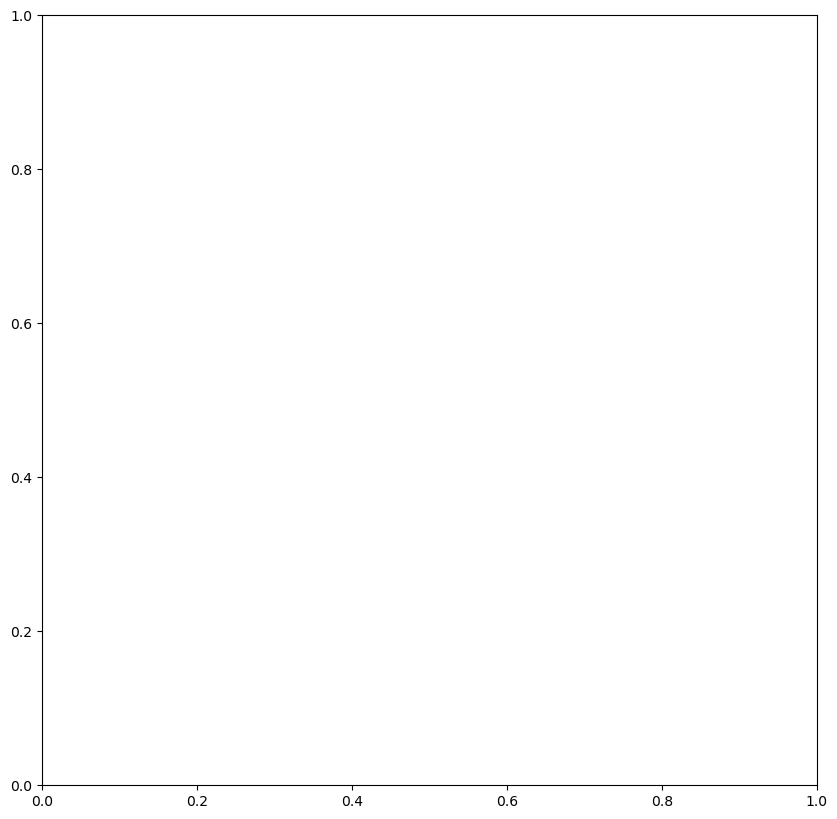

In [35]:
# plt.gray()  # show the filtered result in grayscale
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
ax1.imshow(jim.np())
plt.show()

## Calculate median filter via scipy

In [36]:
from scipy import ndimage
npimage = ndimage.median_filter(jim.np(), size = 5)

NameError: name 'jim' is not defined

NameError: name 'npimage' is not defined

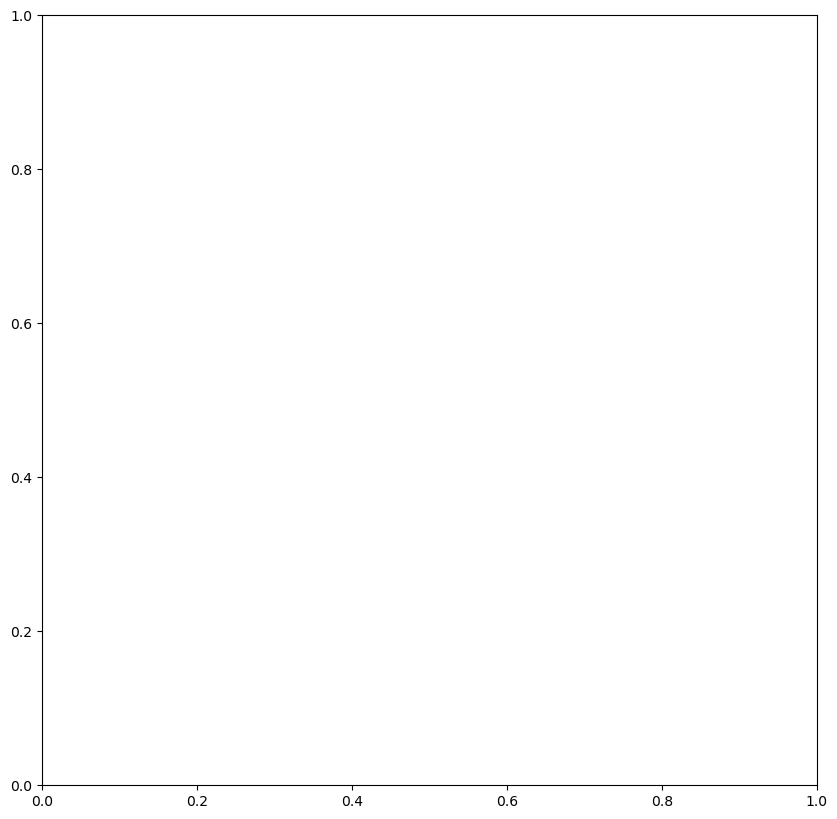

In [37]:
# plt.gray()  # show the filtered result in grayscale
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
ax1.imshow(npimage)
plt.show()

## Exercise 4: Create a geospatial Jim object with CRS from a Numpy array

**A numpy array is not a geospatial dataset with a spatial coordinate reference system !**

In [38]:
ajim = pj.np2jim(npimage)
print(ajim.properties.getProjection())
print(ajim.properties.getGeoTransform())

NameError: name 'pj' is not defined

Use [setProjection](https://pyjeo.readthedocs.io/en/latest/3_reference.html#properties._Properties.setProjection) and [getProjection](https://pyjeo.readthedocs.io/en/latest/3_reference.html#properties._Properties.getProjection) to set the Coordinate Reference System (CRS) of ajim

## Calculating the median_filter in place using the output parameter

In [39]:
ndimage.median_filter(jim.np(), output = jim.np(), size = 5)

NameError: name 'jim' is not defined

As an alternative, we can set the Numpy representation of a Jim object in place

In [40]:
jim.np()[:] = ndimage.median_filter(jim.np(), size = 5)

NameError: name 'jim' is not defined

## Bridging to third party libraries: Xarray

In [41]:
jim.xr()

NameError: name 'jim' is not defined

**An Xarray dataset is defined with a spatial coordinate reference system !**

In [42]:
ajim = pj.xr2jim(jim.xr())

NameError: name 'pj' is not defined

In [43]:
print(ajim.properties.getProjection())
print(ajim.properties.getGeoTransform())

NameError: name 'ajim' is not defined

At the basis we find a Numpy data array

In [44]:
type(jim.xr().ET.data)

NameError: name 'jim' is not defined

### Calculate median filter via Xarray

Processing can take several minutes...

In [45]:
# xr_median = jim.xr().ET.rolling(x = 3, y = 3, center=True).median()

In [46]:
# xr_median.plot()

**Notice that XArray member functions return the processed result and do not alter the input image !**

## Bridging JimVect to third party libraries

In [47]:
sample = pj.JimVect('geodata/shp/polygons.sqlite')

NameError: name 'pj' is not defined

In [48]:
import pandas as pd
pdf = pd.DataFrame(sample.dict())
pdf

NameError: name 'sample' is not defined

## Data extraction and regional statistics

In [49]:
extracted = pj.geometry.extract(sample, jim, rule='mean', output='/vsimem/mean.json', oformat='GeoJSON')

NameError: name 'pj' is not defined

In [50]:
pdf = pd.DataFrame(extracted.dict())
pdf

NameError: name 'extracted' is not defined